# Machine Learning-Based Buyer Segmentation and Investment Profiling for Real Estate Market Intelligence



### Workflow
1. Data loading
2. Data understanding
3. Data cleaning and preprocessing
4. Feature engineering
5. Exploratory data analysis
6. Buyer-level dataset creation
7. Machine learning feature preparation
8. Optimal cluster selection
9. K-Means clustering
10. Hierarchical clustering
11. Cluster interpretation and buyer profiles
12. Business recommendations
13. Exporting final outputs

## 1. Import Libraries

In [2]:
import os
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import dendrogram, linkage

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")

# Create output directories
os.makedirs("../outputs/charts", exist_ok=True)
os.makedirs("../outputs/data", exist_ok=True)
os.makedirs("../outputs/models", exist_ok=True)

print("Libraries imported and output folders are ready.")

Libraries imported and output folders are ready.


## 2. Load Datasets

In [3]:
clients = pd.read_csv("../data/clients.csv")
properties = pd.read_csv("../data/properties.csv")

print("Clients dataset shape:", clients.shape)
print("Properties dataset shape:", properties.shape)

Clients dataset shape: (2000, 12)
Properties dataset shape: (10000, 9)


In [4]:
print("CLIENTS DATASET")
display(clients.head())

print("\nPROPERTIES DATASET")
display(properties.head())

CLIENTS DATASET


,client_id,client_type,first_name,last_name,date_of_birth,gender,country,region,acquisition_purpose,satisfaction_score,loan_applied,referral_channel
0,C0001,Individual,Kareem,Liu,05-11-1968,F,USA,California,Home,4,Yes,Website
1,C0002,Individual,Trystan,Oconnor,11/26/1962,M,USA,California,Home,1,No,Website
2,C0003,Individual,Kale,Gay,04-07-1959,M,USA,California,Home,4,Yes,Agency
3,C0004,Individual,Russell,Gross,11/25/1959,M,USA,California,Home,5,No,Website
4,C0005,Company,Marleez,Co,2/28/1976,M,USA,California,Investment,5,No,Website



PROPERTIES DATASET


,listing_id,tower_number,transaction_date,unit_category,unit_number,floor_area_sqft,sale_price,listing_status,client_ref
0,1012,1,01-01-2024,Apartment,12,1160.36,"$300,385.62",Sold,C0027
1,1015,1,01-01-2024,Apartment,15,782.25,"$208,930.81",Sold,C0097
2,1021,1,01-01-2024,Apartment,21,756.21,"$218,585.92",Sold,C0113
3,1030,1,01-01-2024,Apartment,30,743.09,"$246,172.68",Sold,C0141
4,2016,2,01-01-2024,Apartment,16,701.66,"$212,265.67",Sold,C0146


## 3. Data Understanding

In [5]:
print("CLIENTS DATASET SHAPE:", clients.shape)
print("PROPERTIES DATASET SHAPE:", properties.shape)

print("\nCLIENTS DATASET INFO")
clients.info()

print("\nPROPERTIES DATASET INFO")
properties.info()

CLIENTS DATASET SHAPE: (2000, 12)
PROPERTIES DATASET SHAPE: (10000, 9)

CLIENTS DATASET INFO
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   client_id            2000 non-null   object
 1   client_type          2000 non-null   object
 2   first_name           2000 non-null   object
 3   last_name            2000 non-null   object
 4   date_of_birth        2000 non-null   object
 5   gender               2000 non-null   object
 6   country              2000 non-null   object
 7   region               2000 non-null   object
 8   acquisition_purpose  2000 non-null   object
 9   satisfaction_score   2000 non-null   int64 
 10  loan_applied         2000 non-null   object
 11  referral_channel     2000 non-null   object
dtypes: int64(1), object(11)
memory usage: 187.6+ KB

PROPERTIES DATASET INFO
<class 'pandas.core.frame.DataFrame'

In [6]:
print("MISSING VALUES - CLIENTS")
display(clients.isnull().sum().to_frame("missing_values"))

print("MISSING VALUES - PROPERTIES")
display(properties.isnull().sum().to_frame("missing_values"))

print("Duplicate rows in Clients:", clients.duplicated().sum())
print("Duplicate rows in Properties:", properties.duplicated().sum())

MISSING VALUES - CLIENTS


,missing_values
client_id,0
client_type,0
first_name,0
last_name,0
date_of_birth,0
gender,0
country,0
region,0
acquisition_purpose,0
satisfaction_score,0


MISSING VALUES - PROPERTIES


,missing_values
listing_id,0
tower_number,0
transaction_date,0
unit_category,0
unit_number,0
floor_area_sqft,0
sale_price,0
listing_status,0
client_ref,2695


Duplicate rows in Clients: 0
Duplicate rows in Properties: 0


In [7]:
print("CLIENTS NUMERICAL SUMMARY")
display(clients.describe())

print("PROPERTIES NUMERICAL SUMMARY")
display(properties.describe())

CLIENTS NUMERICAL SUMMARY


,satisfaction_score
count,2000.000000
mean,3.029000
std,1.413562
min,1.000000
25%,2.000000
50%,3.000000
75%,4.000000
max,5.000000


PROPERTIES NUMERICAL SUMMARY


,listing_id,tower_number,unit_number,floor_area_sqft
count,10000.000000,10000.000000,10000.00000,10000.000000
mean,105898.277400,10.370100,28.99920,1139.941412
std,74414.566199,5.769025,16.88242,418.373967
min,1002.000000,1.000000,1.00000,410.710000
25%,50389.750000,5.000000,15.00000,782.200000
50%,100404.500000,10.000000,29.00000,1110.880000
75%,150411.250000,15.000000,43.00000,1499.000000
max,990026.000000,20.000000,70.00000,1957.160000


## 4. Categorical Data Inspection

In [8]:
client_categorical_columns = [
    "client_type", "gender", "country", "region",
    "acquisition_purpose", "loan_applied", "referral_channel"
]

for column in client_categorical_columns:
    print("\n" + "=" * 60)
    print(column.upper())
    print("=" * 60)
    print(clients[column].value_counts(dropna=False))


CLIENT_TYPE
client_type
Individual    1897
Company        103
Name: count, dtype: int64

GENDER
gender
M    1012
F     988
Name: count, dtype: int64

COUNTRY
country
USA          1538
UK             95
Canada         85
Germany        56
France         53
Belgium        43
Mexico         40
Australia      39
Russia         36
Denmark        15
Name: count, dtype: int64

REGION
region
California                633
Nevada                    143
Colorado                  118
Arizona                   108
Oregon                     96
Utah                       87
Washington                 73
Virginia                   65
Texas                      56
Florida                    50
New York                   49
Georgia                    34
England                    29
Alberta                    27
Scotland                   25
Ohio                       24
Northern Ireland           24
British Columbia           20
Wales                      17
Brittany                   16
Flanders    

In [9]:
property_categorical_columns = ["unit_category", "listing_status"]

for column in property_categorical_columns:
    print("\n" + "=" * 60)
    print(column.upper())
    print("=" * 60)
    print(properties[column].value_counts(dropna=False))


UNIT_CATEGORY
unit_category
Apartment    8547
Office       1453
Name: count, dtype: int64

LISTING_STATUS
listing_status
Sold         7305
Available    2695
Name: count, dtype: int64


## 5. Data Cleaning and Preprocessing

The original inspection showed no missing rows and no duplicate rows. The main preprocessing requirements are:
- trimming text fields,
- standardizing categorical labels,
- converting dates,
- converting `sale_price` to numeric,
- validating numerical ranges,
- validating client-property relationships.

In [10]:
clients_clean = clients.copy()
properties_clean = properties.copy()

# Clean client text columns
client_text_columns = [
    "client_type", "first_name", "last_name", "gender", "country",
    "region", "acquisition_purpose", "loan_applied", "referral_channel"
]

for column in client_text_columns:
    clients_clean[column] = clients_clean[column].astype(str).str.strip()

# Clean property text columns
property_text_columns = ["unit_category", "listing_status", "client_ref"]

for column in property_text_columns:
    properties_clean[column] = properties_clean[column].astype(str).str.strip()

print("Text cleaning completed.")

Text cleaning completed.


In [11]:
# Standardize categorical labels
clients_clean["client_type"] = clients_clean["client_type"].str.title()
clients_clean["gender"] = clients_clean["gender"].str.upper()
clients_clean["country"] = clients_clean["country"].str.upper()
clients_clean["region"] = clients_clean["region"].str.title()
clients_clean["acquisition_purpose"] = clients_clean["acquisition_purpose"].str.title()
clients_clean["loan_applied"] = clients_clean["loan_applied"].str.title()
clients_clean["referral_channel"] = clients_clean["referral_channel"].str.title()

properties_clean["unit_category"] = properties_clean["unit_category"].str.title()
properties_clean["listing_status"] = properties_clean["listing_status"].str.title()

# Convert dates
clients_clean["date_of_birth"] = pd.to_datetime(
    clients_clean["date_of_birth"], format="mixed", errors="coerce"
)

properties_clean["transaction_date"] = pd.to_datetime(
    properties_clean["transaction_date"], format="mixed", errors="coerce"
)

print("Invalid DOB values:", clients_clean["date_of_birth"].isna().sum())
print("Invalid transaction dates:", properties_clean["transaction_date"].isna().sum())

Invalid DOB values: 0
Invalid transaction dates: 0


In [12]:
# Convert sale_price to numeric safely
properties_clean["sale_price"] = (
    properties_clean["sale_price"]
    .astype(str)
    .str.replace("$", "", regex=False)
    .str.replace(",", "", regex=False)
    .str.strip()
)

properties_clean["sale_price"] = pd.to_numeric(
    properties_clean["sale_price"], errors="coerce"
)

numeric_property_columns = [
    "listing_id", "tower_number", "unit_number",
    "floor_area_sqft", "sale_price"
]

for column in numeric_property_columns:
    properties_clean[column] = pd.to_numeric(
        properties_clean[column], errors="coerce"
    )

# Remove duplicates if present
clients_clean = clients_clean.drop_duplicates()
properties_clean = properties_clean.drop_duplicates()

print("sale_price dtype:", properties_clean["sale_price"].dtype)
print("Duplicates in Clients:", clients_clean.duplicated().sum())
print("Duplicates in Properties:", properties_clean.duplicated().sum())

sale_price dtype: float64
Duplicates in Clients: 0
Duplicates in Properties: 0


In [13]:
print("DATA VALIDATION RESULTS")

print("Negative or zero floor area:",
      (properties_clean["floor_area_sqft"] <= 0).sum())

print("Negative or zero sale price:",
      (properties_clean["sale_price"] <= 0).sum())

print("Invalid satisfaction scores:",
      (~clients_clean["satisfaction_score"].between(1, 5)).sum())

unmatched_properties = properties_clean[
    ~properties_clean["client_ref"].isin(clients_clean["client_id"])
]

print("Unmatched property client references:", len(unmatched_properties))

print("\nFINAL DATA CLEANING SUMMARY")
print("Clients shape:", clients_clean.shape)
print("Clients missing values:", clients_clean.isnull().sum().sum())
print("Clients duplicate rows:", clients_clean.duplicated().sum())

print("\nProperties shape:", properties_clean.shape)
print("Properties missing values:", properties_clean.isnull().sum().sum())
print("Properties duplicate rows:", properties_clean.duplicated().sum())

DATA VALIDATION RESULTS
Negative or zero floor area: 0
Negative or zero sale price: 0
Invalid satisfaction scores: 0
Unmatched property client references: 2695

FINAL DATA CLEANING SUMMARY
Clients shape: (2000, 12)
Clients missing values: 0
Clients duplicate rows: 0

Properties shape: (10000, 9)
Properties missing values: 0
Properties duplicate rows: 0


## 6. Feature Engineering

### 6.1 Create Buyer Age

In [14]:
today = pd.Timestamp.today()

clients_clean["age"] = today.year - clients_clean["date_of_birth"].dt.year

birthday_not_occurred = (
    (today.month < clients_clean["date_of_birth"].dt.month) |
    (
        (today.month == clients_clean["date_of_birth"].dt.month) &
        (today.day < clients_clean["date_of_birth"].dt.day)
    )
)

clients_clean.loc[birthday_not_occurred, "age"] -= 1

print("Minimum age:", clients_clean["age"].min())
print("Maximum age:", clients_clean["age"].max())

suspicious_age = clients_clean[
    (clients_clean["age"] < 18) | (clients_clean["age"] > 100)
]

print("Suspicious age records:", len(suspicious_age))
display(clients_clean[["client_id", "date_of_birth", "age"]].head())

Minimum age: 25
Maximum age: 95
Suspicious age records: 0


,client_id,date_of_birth,age
0,C0001,1968-05-11,58
1,C0002,1962-11-26,63
2,C0003,1959-04-07,67
3,C0004,1959-11-25,66
4,C0005,1976-02-28,50


### 6.2 Aggregate Property Information to Buyer Level

In [15]:
buyer_property_summary = (
    properties_clean
    .groupby("client_ref")
    .agg(
        total_properties=("listing_id", "count"),
        total_investment=("sale_price", "sum"),
        average_property_price=("sale_price", "mean"),
        max_property_price=("sale_price", "max"),
        min_property_price=("sale_price", "min"),
        average_property_area=("floor_area_sqft", "mean"),
        total_property_area=("floor_area_sqft", "sum")
    )
    .reset_index()
)

print("Buyer property summary shape:", buyer_property_summary.shape)
display(buyer_property_summary.head())

Buyer property summary shape: (2001, 8)


,client_ref,total_properties,total_investment,average_property_price,max_property_price,min_property_price,average_property_area,total_property_area
0,C0001,4,1246764.72,311691.180000,496266.41,175599.90,983.885000,3935.54
1,C0002,5,1841095.93,368219.186000,505127.63,248525.12,1187.942000,5939.71
2,C0003,5,1661457.59,332291.518000,584611.99,216874.97,1058.110000,5290.55
3,C0004,6,1608263.51,268043.918333,606634.75,149009.73,937.103333,5622.62
4,C0005,13,3653385.38,281029.644615,628812.33,189194.31,927.296154,12054.85


### 6.3 Create Final Buyer-Level Dataset

In [16]:
buyer_data = clients_clean.merge(
    buyer_property_summary,
    left_on="client_id",
    right_on="client_ref",
    how="left"
)

buyer_data.drop(columns="client_ref", inplace=True)

property_feature_columns = [
    "total_properties",
    "total_investment",
    "average_property_price",
    "max_property_price",
    "min_property_price",
    "average_property_area",
    "total_property_area"
]

print("Missing property features before handling:")
display(buyer_data[property_feature_columns].isnull().sum().to_frame("missing_values"))

# If any client has no property record, use zero for property-based aggregates
buyer_data[property_feature_columns] = buyer_data[property_feature_columns].fillna(0)

print("\nFinal buyer-level dataset shape:", buyer_data.shape)
display(buyer_data.head())

Missing property features before handling:


,missing_values
total_properties,0
total_investment,0
average_property_price,0
max_property_price,0
min_property_price,0
average_property_area,0
total_property_area,0



Final buyer-level dataset shape: (2000, 20)


,client_id,client_type,first_name,last_name,date_of_birth,gender,country,region,acquisition_purpose,satisfaction_score,loan_applied,referral_channel,age,total_properties,total_investment,average_property_price,max_property_price,min_property_price,average_property_area,total_property_area
0,C0001,Individual,Kareem,Liu,1968-05-11,F,USA,California,Home,4,Yes,Website,58,4,1246764.72,311691.180000,496266.41,175599.90,983.885000,3935.54
1,C0002,Individual,Trystan,Oconnor,1962-11-26,M,USA,California,Home,1,No,Website,63,5,1841095.93,368219.186000,505127.63,248525.12,1187.942000,5939.71
2,C0003,Individual,Kale,Gay,1959-04-07,M,USA,California,Home,4,Yes,Agency,67,5,1661457.59,332291.518000,584611.99,216874.97,1058.110000,5290.55
3,C0004,Individual,Russell,Gross,1959-11-25,M,USA,California,Home,5,No,Website,66,6,1608263.51,268043.918333,606634.75,149009.73,937.103333,5622.62
4,C0005,Company,Marleez,Co,1976-02-28,M,USA,California,Investment,5,No,Website,50,13,3653385.38,281029.644615,628812.33,189194.31,927.296154,12054.85


In [17]:
print("FEATURE ENGINEERING SUMMARY")

display(
    buyer_data[
        [
            "age", "satisfaction_score", "total_properties",
            "total_investment", "average_property_price",
            "average_property_area"
        ]
    ].describe()
)

FEATURE ENGINEERING SUMMARY


,age,satisfaction_score,total_properties,total_investment,average_property_price,average_property_area
count,2000.000000,2000.000000,2000.0000,2.000000e+03,2000.000000,2000.000000
mean,55.783000,3.029000,3.6525,1.260375e+06,347089.955869,1147.479668
std,17.361095,1.413562,0.8397,3.478307e+05,69721.821814,219.922587
min,25.000000,1.000000,3.0000,4.636120e+05,154537.316667,564.010000
25%,41.000000,2.000000,3.0000,1.025238e+06,295807.677708,984.952500
50%,56.000000,3.000000,4.0000,1.220893e+06,341523.383333,1129.176667
75%,70.000000,4.000000,4.0000,1.441974e+06,390843.316875,1296.562500
max,95.000000,5.000000,13.0000,3.653385e+06,563423.500000,1800.450000


## 7. Exploratory Data Analysis (EDA)

### 7.1 Helper Function for Saving Charts

In [18]:
def save_and_show(filename):
    plt.tight_layout()
    plt.savefig(f"../outputs/charts/{filename}", dpi=300, bbox_inches="tight")
    plt.show()

### 7.2 Buyer Demographics and Behavior

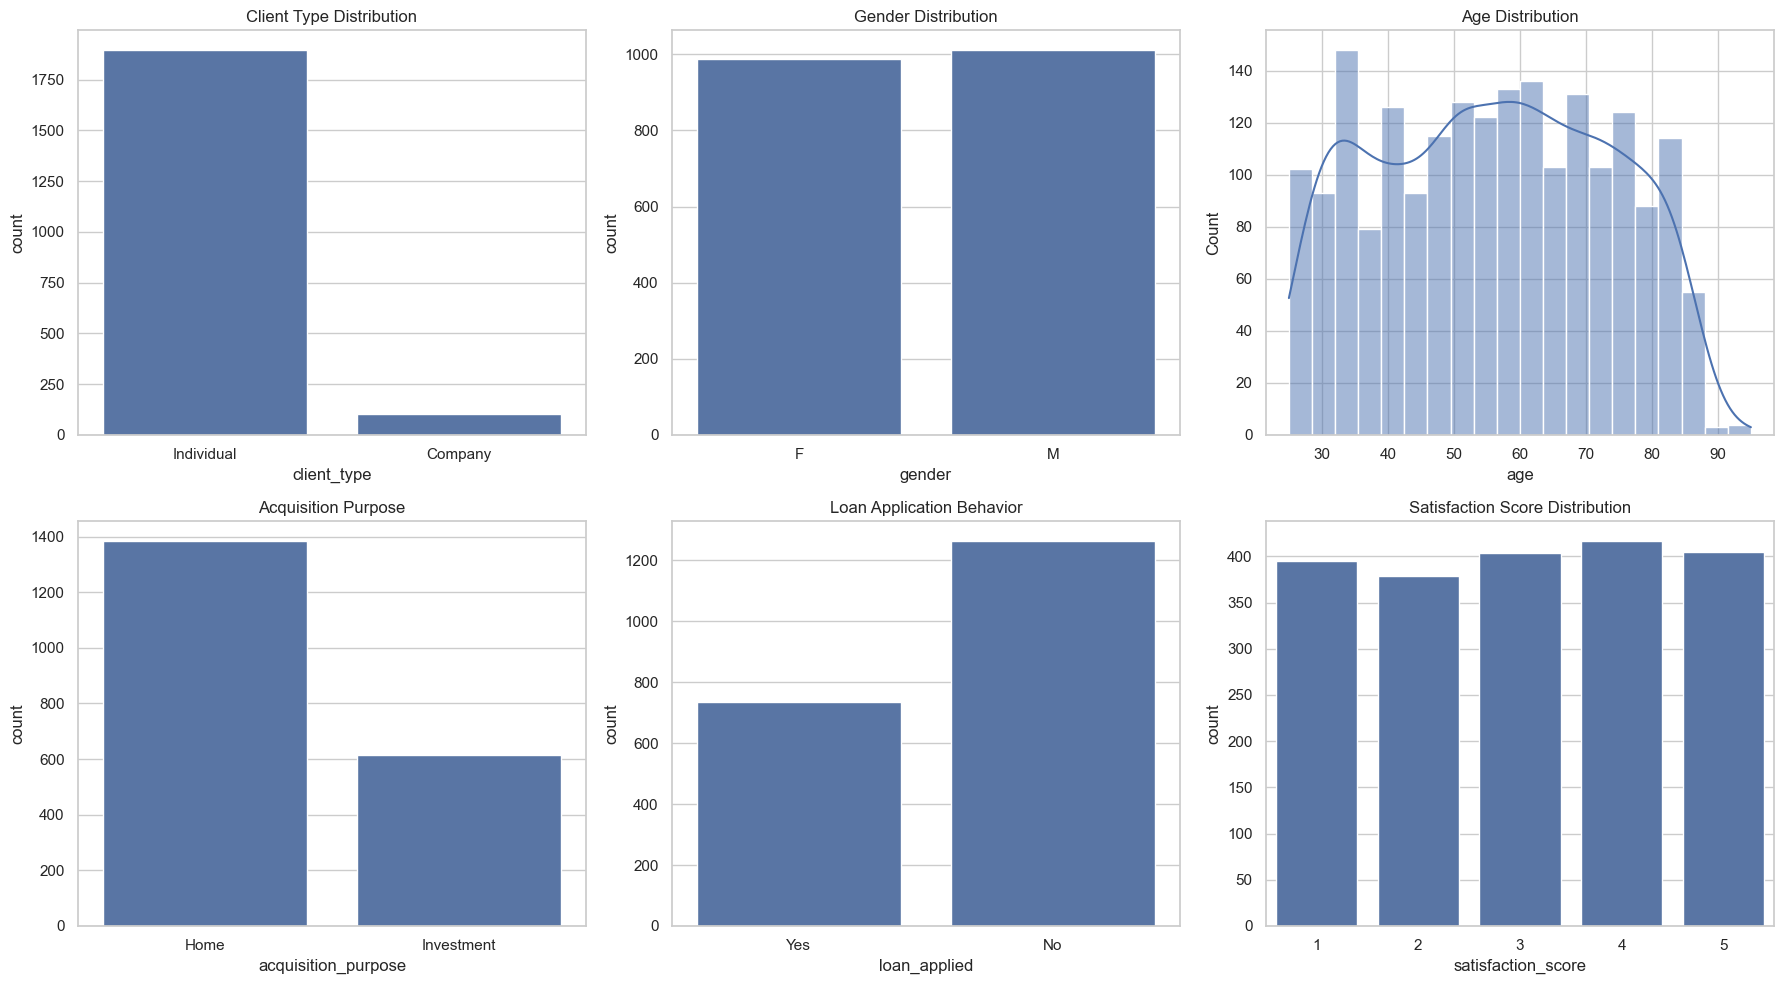

In [19]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

sns.countplot(data=buyer_data, x="client_type", ax=axes[0, 0])
axes[0, 0].set_title("Client Type Distribution")

sns.countplot(data=buyer_data, x="gender", ax=axes[0, 1])
axes[0, 1].set_title("Gender Distribution")

sns.histplot(data=buyer_data, x="age", bins=20, kde=True, ax=axes[0, 2])
axes[0, 2].set_title("Age Distribution")

sns.countplot(data=buyer_data, x="acquisition_purpose", ax=axes[1, 0])
axes[1, 0].set_title("Acquisition Purpose")

sns.countplot(data=buyer_data, x="loan_applied", ax=axes[1, 1])
axes[1, 1].set_title("Loan Application Behavior")

sns.countplot(data=buyer_data, x="satisfaction_score", ax=axes[1, 2])
axes[1, 2].set_title("Satisfaction Score Distribution")

plt.tight_layout()
plt.savefig("../outputs/charts/01_buyer_demographics_behavior.png", dpi=300, bbox_inches="tight")
plt.show()

### 7.3 Geographic Analysis

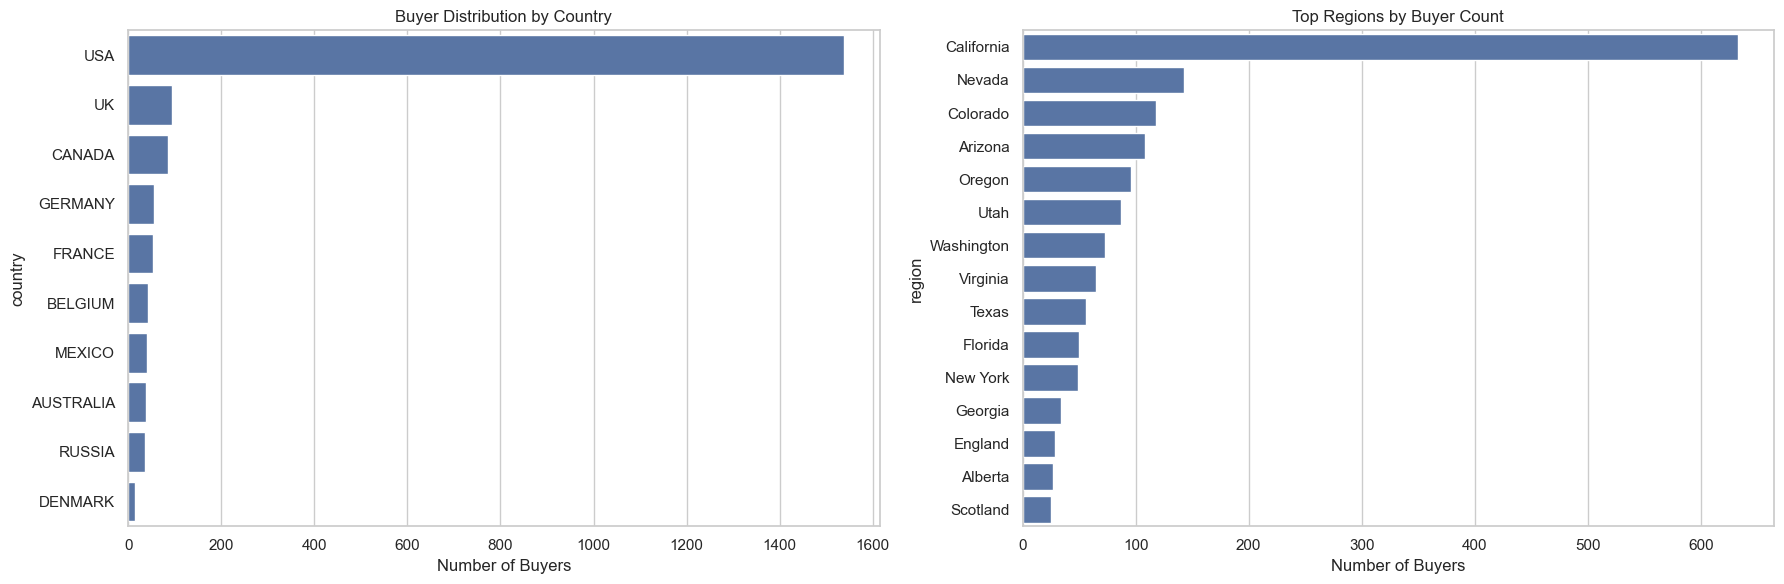

In [20]:
country_counts = buyer_data["country"].value_counts()
region_counts = buyer_data["region"].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

sns.barplot(x=country_counts.values, y=country_counts.index, ax=axes[0])
axes[0].set_title("Buyer Distribution by Country")
axes[0].set_xlabel("Number of Buyers")

top_regions = region_counts.head(15)
sns.barplot(x=top_regions.values, y=top_regions.index, ax=axes[1])
axes[1].set_title("Top Regions by Buyer Count")
axes[1].set_xlabel("Number of Buyers")

plt.tight_layout()
plt.savefig("../outputs/charts/02_geographic_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

### 7.4 Investment and Property Analysis

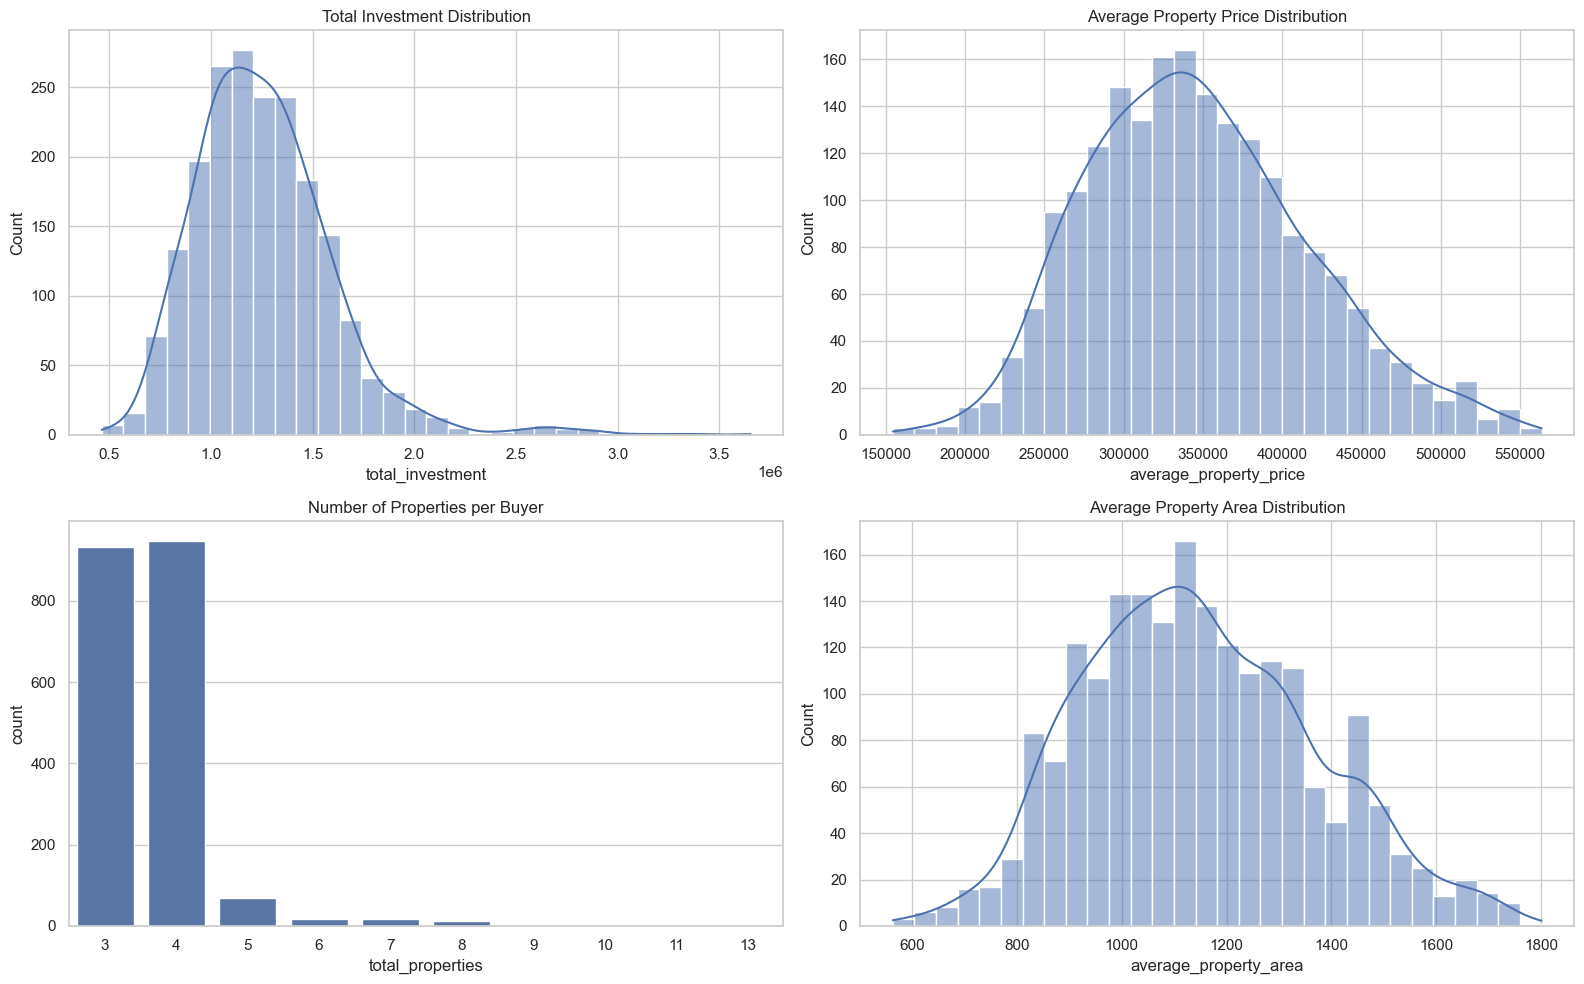

In [21]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

sns.histplot(data=buyer_data, x="total_investment", bins=30, kde=True, ax=axes[0, 0])
axes[0, 0].set_title("Total Investment Distribution")

sns.histplot(data=buyer_data, x="average_property_price", bins=30, kde=True, ax=axes[0, 1])
axes[0, 1].set_title("Average Property Price Distribution")

sns.countplot(data=buyer_data, x="total_properties", ax=axes[1, 0])
axes[1, 0].set_title("Number of Properties per Buyer")

sns.histplot(data=buyer_data, x="average_property_area", bins=30, kde=True, ax=axes[1, 1])
axes[1, 1].set_title("Average Property Area Distribution")

plt.tight_layout()
plt.savefig("../outputs/charts/03_investment_property_analysis.png", dpi=300, bbox_inches="tight")
plt.show()

### 7.5 Relationship Analysis

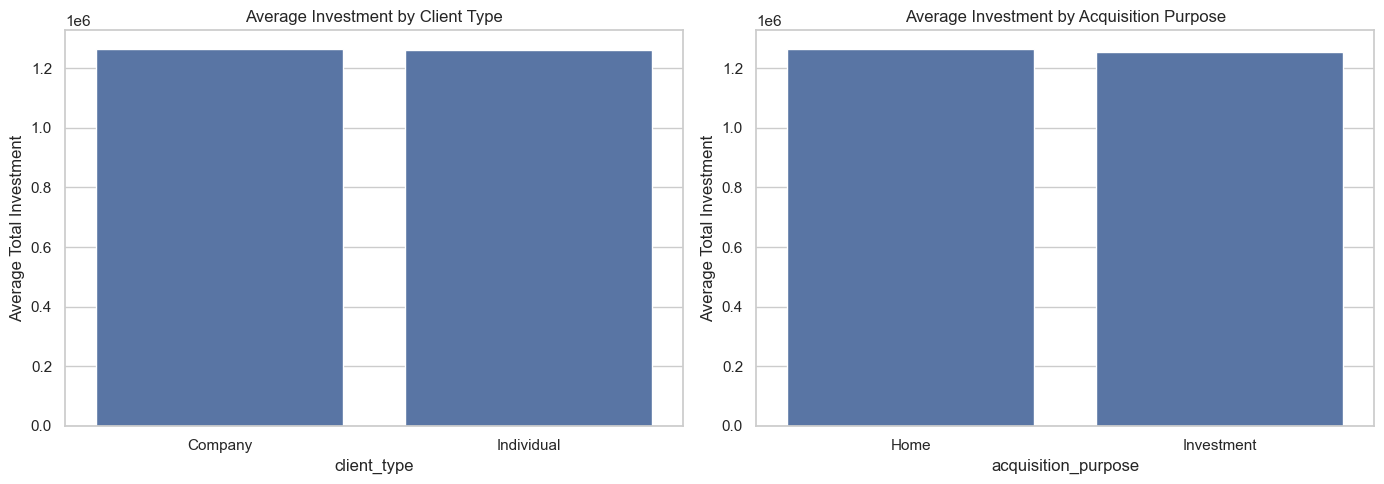

Average investment by client type:


,average_investment
client_type,
Company,1.263753e+06
Individual,1.260192e+06


Average investment by acquisition purpose:


,average_investment
acquisition_purpose,
Home,1.263588e+06
Investment,1.253142e+06


In [22]:
investment_by_client_type = (
    buyer_data.groupby("client_type")["total_investment"]
    .mean()
    .sort_values(ascending=False)
)

investment_by_purpose = (
    buyer_data.groupby("acquisition_purpose")["total_investment"]
    .mean()
    .sort_values(ascending=False)
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(x=investment_by_client_type.index, y=investment_by_client_type.values, ax=axes[0])
axes[0].set_title("Average Investment by Client Type")
axes[0].set_ylabel("Average Total Investment")

sns.barplot(x=investment_by_purpose.index, y=investment_by_purpose.values, ax=axes[1])
axes[1].set_title("Average Investment by Acquisition Purpose")
axes[1].set_ylabel("Average Total Investment")

plt.tight_layout()
plt.savefig("../outputs/charts/04_investment_relationships.png", dpi=300, bbox_inches="tight")
plt.show()

print("Average investment by client type:")
display(investment_by_client_type.to_frame("average_investment"))

print("Average investment by acquisition purpose:")
display(investment_by_purpose.to_frame("average_investment"))

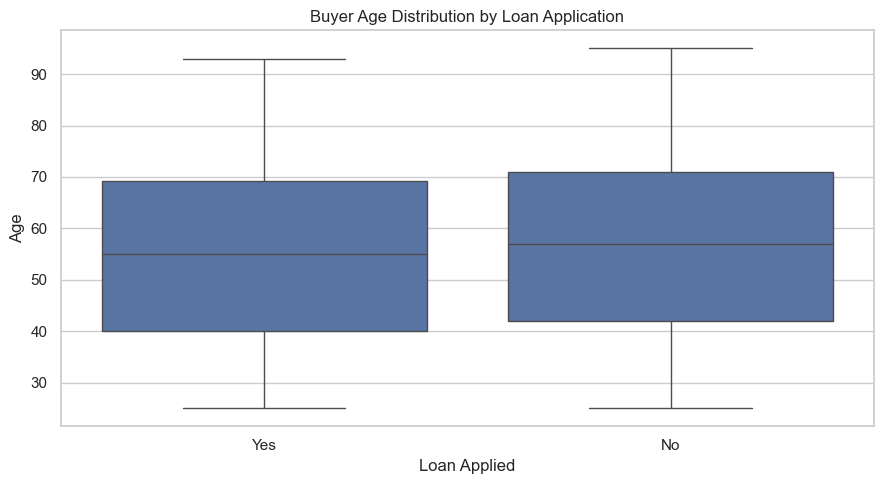

In [23]:
plt.figure(figsize=(9, 5))

sns.boxplot(data=buyer_data, x="loan_applied", y="age")

plt.title("Buyer Age Distribution by Loan Application")
plt.xlabel("Loan Applied")
plt.ylabel("Age")

save_and_show("05_age_by_loan_behavior.png")

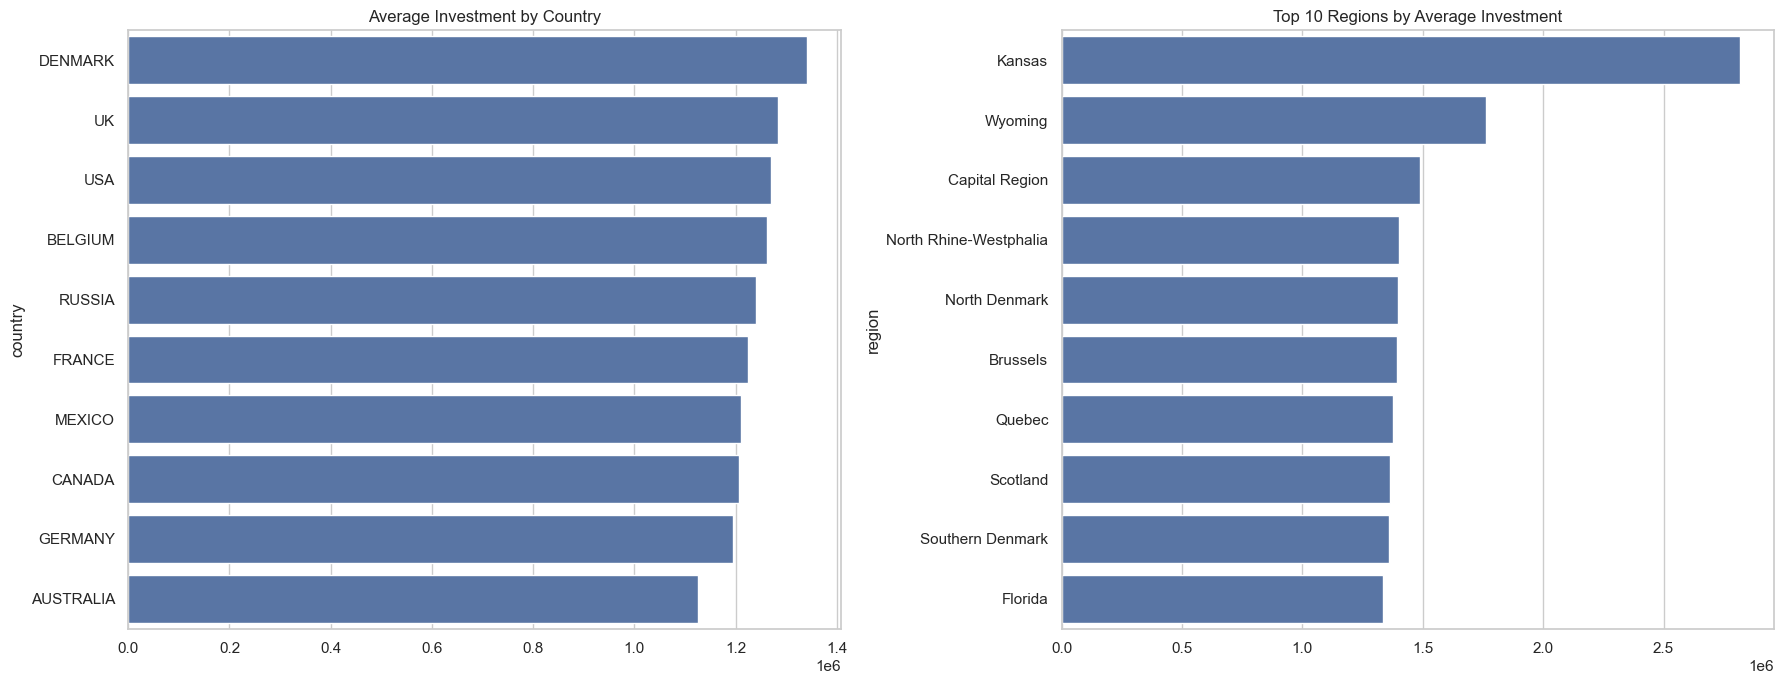

In [24]:
country_investment = (
    buyer_data.groupby("country")["total_investment"]
    .mean()
    .sort_values(ascending=False)
)

region_investment = (
    buyer_data.groupby("region")["total_investment"]
    .mean()
    .sort_values(ascending=False)
)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

sns.barplot(x=country_investment.values, y=country_investment.index, ax=axes[0])
axes[0].set_title("Average Investment by Country")

top_region_investment = region_investment.head(10)
sns.barplot(x=top_region_investment.values, y=top_region_investment.index, ax=axes[1])
axes[1].set_title("Top 10 Regions by Average Investment")

plt.tight_layout()
plt.savefig("../outputs/charts/06_geographic_investment.png", dpi=300, bbox_inches="tight")
plt.show()

### 7.6 Correlation Analysis

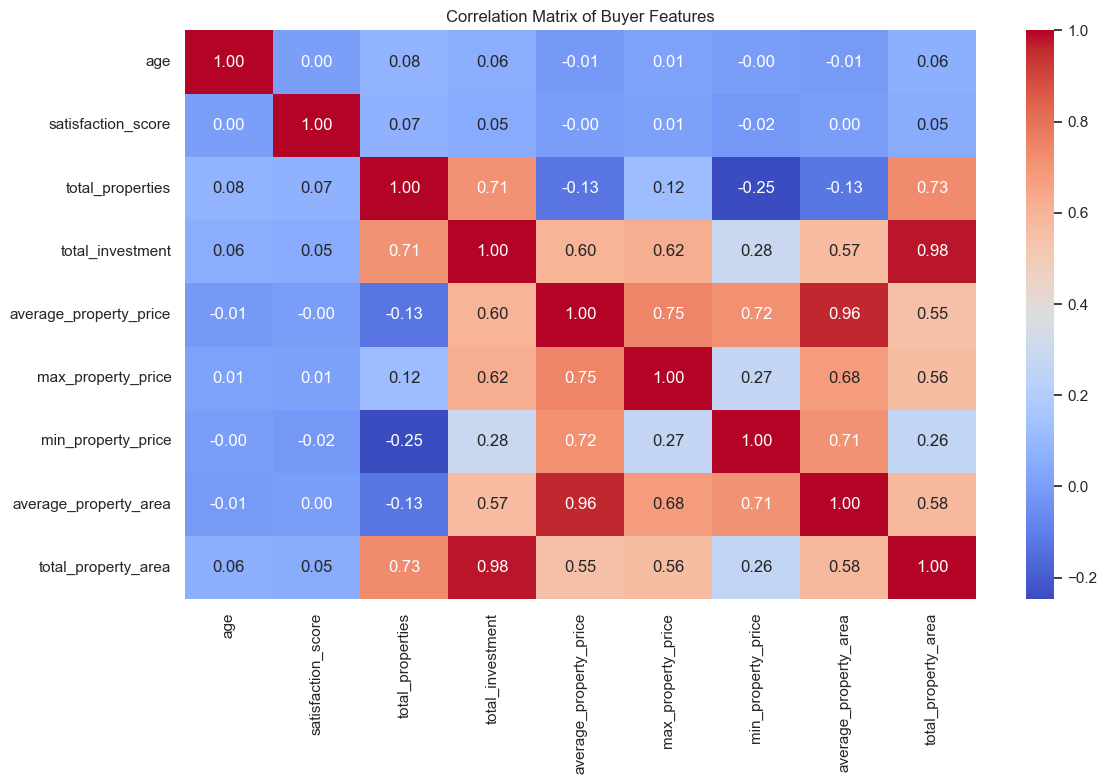

In [25]:
correlation_columns = [
    "age",
    "satisfaction_score",
    "total_properties",
    "total_investment",
    "average_property_price",
    "max_property_price",
    "min_property_price",
    "average_property_area",
    "total_property_area"
]

correlation_matrix = buyer_data[correlation_columns].corr()

plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Matrix of Buyer Features")

save_and_show("07_correlation_matrix.png")

## 8. Preparing Data for Machine Learning

### Feature Selection Rationale
The clustering model uses features that describe:
- demographics,
- client type,
- geography,
- acquisition purpose,
- financing behavior,
- customer satisfaction,
- property ownership,
- investment value.

The following columns are excluded because they are identifiers or personally identifying fields:
`client_id`, `first_name`, `last_name`, and `date_of_birth`.

In [26]:
numeric_features = [
    "age",
    "satisfaction_score",
    "total_properties",
    "total_investment",
    "average_property_price",
    "average_property_area"
]

categorical_features = [
    "client_type",
    "gender",
    "country",
    "region",
    "acquisition_purpose",
    "loan_applied",
    "referral_channel"
]

ml_features = numeric_features + categorical_features

X = buyer_data[ml_features].copy()

print("Selected ML features:")
print(ml_features)
print("\nInput shape:", X.shape)
display(X.head())

Selected ML features:
['age', 'satisfaction_score', 'total_properties', 'total_investment', 'average_property_price', 'average_property_area', 'client_type', 'gender', 'country', 'region', 'acquisition_purpose', 'loan_applied', 'referral_channel']

Input shape: (2000, 13)


,age,satisfaction_score,total_properties,total_investment,average_property_price,average_property_area,client_type,gender,country,region,acquisition_purpose,loan_applied,referral_channel
0,58,4,4,1246764.72,311691.180000,983.885000,Individual,F,USA,California,Home,Yes,Website
1,63,1,5,1841095.93,368219.186000,1187.942000,Individual,M,USA,California,Home,No,Website
2,67,4,5,1661457.59,332291.518000,1058.110000,Individual,M,USA,California,Home,Yes,Agency
3,66,5,6,1608263.51,268043.918333,937.103333,Individual,M,USA,California,Home,No,Website
4,50,5,13,3653385.38,281029.644615,927.296154,Company,M,USA,California,Investment,No,Website


In [27]:
# Build preprocessing pipeline
try:
    categorical_transformer = OneHotEncoder(
        handle_unknown="ignore",
        sparse_output=False
    )
except TypeError:
    # Compatibility with older scikit-learn versions
    categorical_transformer = OneHotEncoder(
        handle_unknown="ignore",
        sparse=False
    )

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ],
    remainder="drop"
)

X_processed = preprocessor.fit_transform(X)

print("Processed feature matrix shape:", X_processed.shape)

Processed feature matrix shape: (2000, 84)


## 9. Optimal Cluster Selection

### 9.1 Elbow Method and Silhouette Score

In [28]:
k_values = range(2, 9)

inertias = []
silhouette_scores = []

for k in k_values:
    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=20
    )

    labels = model.fit_predict(X_processed)

    inertias.append(model.inertia_)
    silhouette_scores.append(
        silhouette_score(X_processed, labels)
    )

cluster_evaluation = pd.DataFrame({
    "k": list(k_values),
    "inertia": inertias,
    "silhouette_score": silhouette_scores
})

display(cluster_evaluation)

,k,inertia,silhouette_score
0,2,15377.831547,0.159414
1,3,13964.635040,0.166185
2,4,13025.131108,0.118179
3,5,12332.575186,0.099319
4,6,11795.411678,0.095083
5,7,11378.725688,0.095480
6,8,11018.109523,0.090066


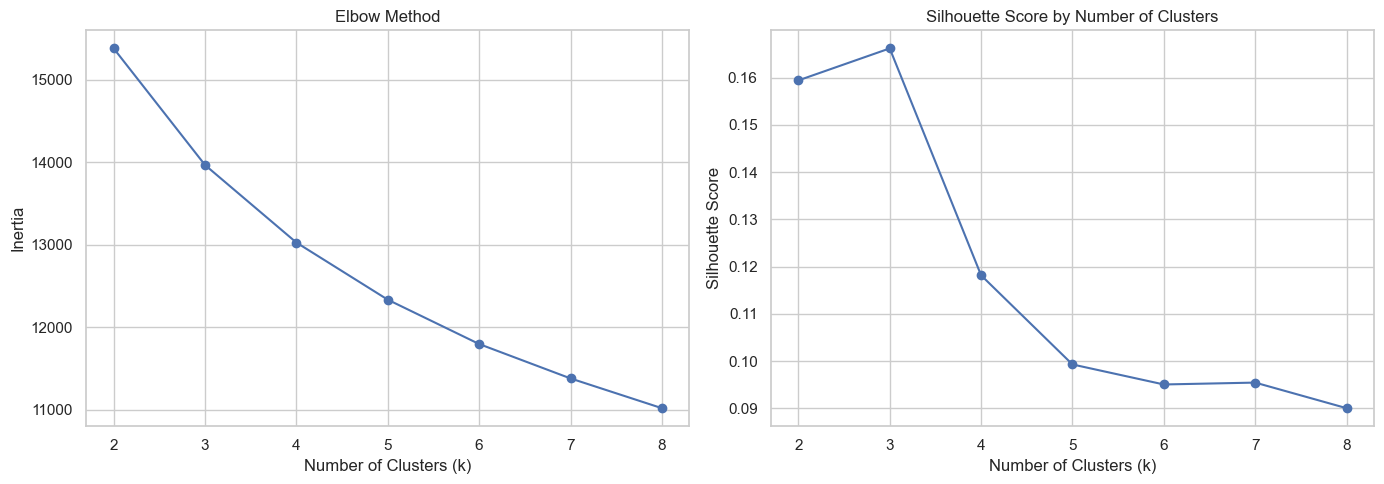

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(cluster_evaluation["k"], cluster_evaluation["inertia"], marker="o")
axes[0].set_title("Elbow Method")
axes[0].set_xlabel("Number of Clusters (k)")
axes[0].set_ylabel("Inertia")

axes[1].plot(cluster_evaluation["k"], cluster_evaluation["silhouette_score"], marker="o")
axes[1].set_title("Silhouette Score by Number of Clusters")
axes[1].set_xlabel("Number of Clusters (k)")
axes[1].set_ylabel("Silhouette Score")

plt.tight_layout()
plt.savefig("../outputs/charts/08_cluster_selection.png", dpi=300, bbox_inches="tight")
plt.show()

### 9.2 Select the Final Number of Clusters

The silhouette score is used as the primary objective measure. The elbow plot should also be reviewed for business interpretability.

In [30]:
best_k = int(
    cluster_evaluation.loc[
        cluster_evaluation["silhouette_score"].idxmax(),
        "k"
    ]
)

print("Best k based on the highest silhouette score:", best_k)
print("Silhouette score:", cluster_evaluation.loc[
    cluster_evaluation["silhouette_score"].idxmax(),
    "silhouette_score"
])

Best k based on the highest silhouette score: 3
Silhouette score: 0.16618506188978047


## 10. K-Means Clustering

In [31]:
kmeans = KMeans(
    n_clusters=best_k,
    random_state=42,
    n_init=20
)

buyer_data["cluster"] = kmeans.fit_predict(X_processed)

kmeans_silhouette = silhouette_score(
    X_processed,
    buyer_data["cluster"]
)

print("K-Means completed successfully.")
print("Number of clusters:", best_k)
print("K-Means silhouette score:", round(kmeans_silhouette, 4))

print("\nCluster Distribution:")
display(
    buyer_data["cluster"]
    .value_counts()
    .sort_index()
    .to_frame("number_of_buyers")
)

K-Means completed successfully.
Number of clusters: 3
K-Means silhouette score: 0.1662

Cluster Distribution:


,number_of_buyers
cluster,
0,50
1,848
2,1102


## 11. Hierarchical Clustering

### 11.1 Dendrogram

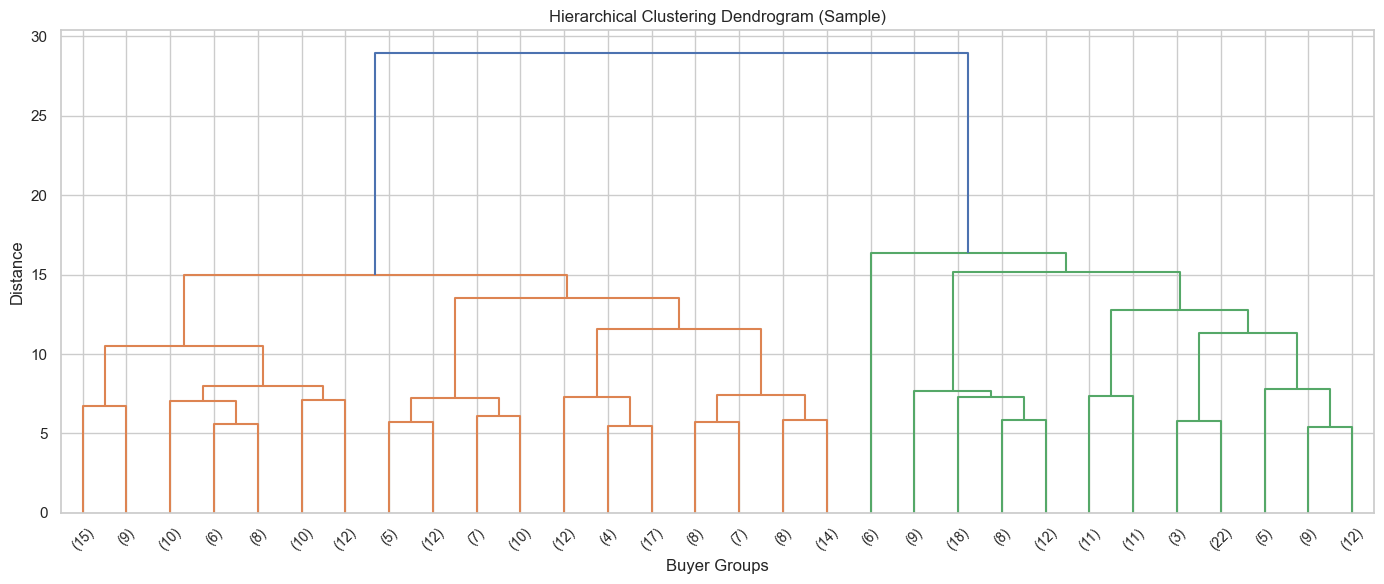

In [32]:
# A sample is used for visualization because a dendrogram with all 2000 buyers is unreadable.
sample_size = min(300, len(X_processed))
rng = np.random.default_rng(42)
sample_indices = rng.choice(
    len(X_processed),
    size=sample_size,
    replace=False
)

X_sample = X_processed[sample_indices]

linked = linkage(X_sample, method="ward")

plt.figure(figsize=(14, 6))
dendrogram(
    linked,
    truncate_mode="lastp",
    p=30,
    show_leaf_counts=True
)

plt.title("Hierarchical Clustering Dendrogram (Sample)")
plt.xlabel("Buyer Groups")
plt.ylabel("Distance")

save_and_show("09_hierarchical_dendrogram.png")

### 11.2 Agglomerative Clustering Validation

In [33]:
hierarchical_model = AgglomerativeClustering(
    n_clusters=best_k,
    linkage="ward"
)

buyer_data["hierarchical_cluster"] = hierarchical_model.fit_predict(
    X_processed
)

hierarchical_silhouette = silhouette_score(
    X_processed,
    buyer_data["hierarchical_cluster"]
)

print("Hierarchical clustering silhouette score:",
      round(hierarchical_silhouette, 4))

display(
    buyer_data["hierarchical_cluster"]
    .value_counts()
    .sort_index()
    .to_frame("number_of_buyers")
)

Hierarchical clustering silhouette score: 0.1395


,number_of_buyers
hierarchical_cluster,
0,1331
1,631
2,38


## 12. Cluster Interpretation and Buyer Profiling

The cluster profiles below are generated from the actual data. This is preferable to assigning names such as "Luxury Investor" before examining the cluster characteristics.

In [34]:
cluster_numeric_profile = (
    buyer_data
    .groupby("cluster")
    [
        [
            "age",
            "satisfaction_score",
            "total_properties",
            "total_investment",
            "average_property_price",
            "average_property_area"
        ]
    ]
    .mean()
    .round(2)
)

cluster_size = (
    buyer_data
    .groupby("cluster")
    .size()
    .rename("buyer_count")
)

cluster_profile = (
    cluster_numeric_profile
    .join(cluster_size)
)

display(cluster_profile)

,age,satisfaction_score,total_properties,total_investment,average_property_price,average_property_area,buyer_count
cluster,,,,,,,
0,63.98,3.52,7.32,2416602.86,332747.25,1101.05,50
1,55.25,3.07,3.58,1459397.24,410549.52,1348.26,848
2,55.82,2.97,3.54,1054765.84,298907.95,995.08,1102


In [35]:
# Dominant categorical characteristics for each cluster
profile_rows = []

for cluster_id, group in buyer_data.groupby("cluster"):
    row = {
        "cluster": cluster_id,
        "buyer_count": len(group),
        "dominant_client_type": group["client_type"].mode().iloc[0],
        "dominant_country": group["country"].mode().iloc[0],
        "dominant_region": group["region"].mode().iloc[0],
        "dominant_acquisition_purpose": group["acquisition_purpose"].mode().iloc[0],
        "dominant_loan_behavior": group["loan_applied"].mode().iloc[0],
        "average_age": round(group["age"].mean(), 2),
        "average_satisfaction": round(group["satisfaction_score"].mean(), 2),
        "average_properties": round(group["total_properties"].mean(), 2),
        "average_total_investment": round(group["total_investment"].mean(), 2),
        "average_property_price": round(group["average_property_price"].mean(), 2)
    }
    profile_rows.append(row)

cluster_profiles = pd.DataFrame(profile_rows).sort_values("cluster")

display(cluster_profiles)

,cluster,buyer_count,dominant_client_type,dominant_country,dominant_region,dominant_acquisition_purpose,dominant_loan_behavior,average_age,average_satisfaction,average_properties,average_total_investment,average_property_price
0,0,50,Individual,USA,California,Home,No,63.98,3.52,7.32,2416602.86,332747.25
1,1,848,Individual,USA,California,Home,No,55.25,3.07,3.58,1459397.24,410549.52
2,2,1102,Individual,USA,California,Home,No,55.82,2.97,3.54,1054765.84,298907.95


### 12.1 Create Business-Friendly Segment Names from Actual Cluster Characteristics

In [36]:
# Rank clusters by average investment and property ownership.
investment_rank = (
    buyer_data.groupby("cluster")["total_investment"]
    .mean()
    .rank(method="dense", ascending=False)
)

property_rank = (
    buyer_data.groupby("cluster")["total_properties"]
    .mean()
    .rank(method="dense", ascending=False)
)

segment_name_map = {}

for cluster_id in sorted(buyer_data["cluster"].unique()):
    inv_rank = investment_rank.loc[cluster_id]
    prop_rank = property_rank.loc[cluster_id]

    purpose = (
        buyer_data.loc[
            buyer_data["cluster"] == cluster_id,
            "acquisition_purpose"
        ]
        .mode()
        .iloc[0]
    )

    loan_rate = (
        buyer_data.loc[
            buyer_data["cluster"] == cluster_id,
            "loan_applied"
        ]
        .eq("Yes")
        .mean()
    )

    if inv_rank == 1:
        name = "High-Value Investors"
    elif prop_rank == 1:
        name = "Portfolio Buyers"
    elif purpose == "Home" and loan_rate >= 0.5:
        name = "Financing-Oriented Home Buyers"
    elif purpose == "Home":
        name = "Home-Focused Buyers"
    else:
        name = "Investment-Focused Buyers"

    # Ensure unique names when two clusters meet similar rules
    if name in segment_name_map.values():
        name = f"{name} - Cluster {cluster_id}"

    segment_name_map[cluster_id] = name

buyer_data["segment_name"] = buyer_data["cluster"].map(segment_name_map)

print("Segment Names:")
for cluster_id, name in segment_name_map.items():
    print(f"Cluster {cluster_id}: {name}")

display(
    buyer_data[
        ["cluster", "segment_name"]
    ]
    .drop_duplicates()
    .sort_values("cluster")
)

Segment Names:
Cluster 0: High-Value Investors
Cluster 1: Home-Focused Buyers
Cluster 2: Home-Focused Buyers - Cluster 2


,cluster,segment_name
3,0,High-Value Investors
1,1,Home-Focused Buyers
0,2,Home-Focused Buyers - Cluster 2


### 12.2 Cluster Visualization

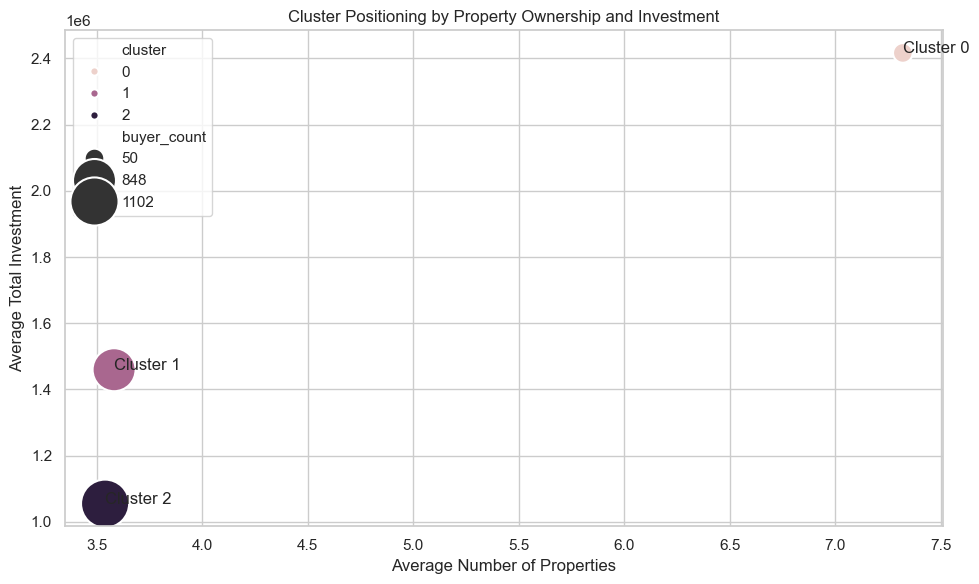

In [37]:
cluster_plot_data = buyer_data.groupby("cluster").agg(
    buyer_count=("client_id", "count"),
    average_investment=("total_investment", "mean"),
    average_properties=("total_properties", "mean")
).reset_index()

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=cluster_plot_data,
    x="average_properties",
    y="average_investment",
    size="buyer_count",
    hue="cluster",
    sizes=(200, 1200),
    legend=True
)

for _, row in cluster_plot_data.iterrows():
    plt.text(
        row["average_properties"],
        row["average_investment"],
        f"Cluster {int(row['cluster'])}"
    )

plt.title("Cluster Positioning by Property Ownership and Investment")
plt.xlabel("Average Number of Properties")
plt.ylabel("Average Total Investment")

save_and_show("10_cluster_positioning.png")

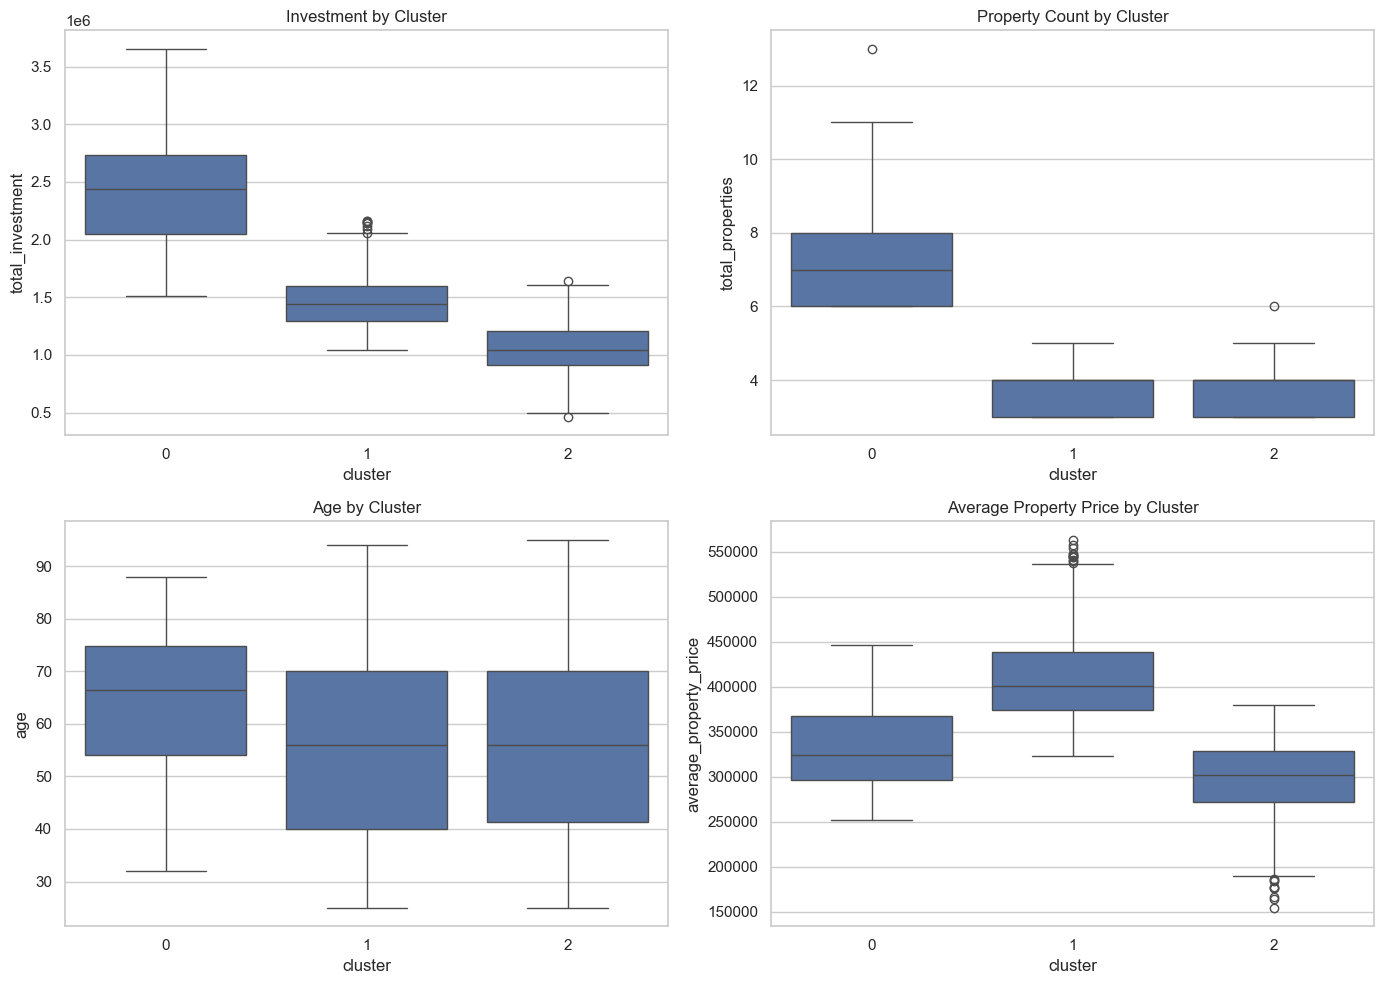

In [38]:
# Compare major numerical characteristics across clusters
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.boxplot(data=buyer_data, x="cluster", y="total_investment", ax=axes[0, 0])
axes[0, 0].set_title("Investment by Cluster")

sns.boxplot(data=buyer_data, x="cluster", y="total_properties", ax=axes[0, 1])
axes[0, 1].set_title("Property Count by Cluster")

sns.boxplot(data=buyer_data, x="cluster", y="age", ax=axes[1, 0])
axes[1, 0].set_title("Age by Cluster")

sns.boxplot(data=buyer_data, x="cluster", y="average_property_price", ax=axes[1, 1])
axes[1, 1].set_title("Average Property Price by Cluster")

plt.tight_layout()
plt.savefig("../outputs/charts/11_cluster_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

## 13. Recommended Buyer Segments and Business Recommendations

The exact segment names and characteristics should be based on the generated cluster profiles. The following recommendations provide an actionable business framework.

In [39]:
recommendation_rows = []

for cluster_id, group in buyer_data.groupby("cluster"):
    segment = group["segment_name"].iloc[0]
    avg_investment = group["total_investment"].mean()
    avg_properties = group["total_properties"].mean()
    dominant_purpose = group["acquisition_purpose"].mode().iloc[0]
    loan_rate = group["loan_applied"].eq("Yes").mean()

    if avg_investment >= buyer_data["total_investment"].median():
        recommendation = (
            "Prioritize premium investment opportunities, dedicated account management, "
            "and high-value property recommendations."
        )
    elif loan_rate >= 0.5:
        recommendation = (
            "Provide financing guidance, loan partnerships, affordability tools, "
            "and targeted first-home purchase campaigns."
        )
    elif dominant_purpose == "Home":
        recommendation = (
            "Focus on personalized home recommendations, location-based marketing, "
            "and family or lifestyle-oriented property campaigns."
        )
    else:
        recommendation = (
            "Promote investment-oriented properties, portfolio analytics, "
            "and market-return insights."
        )

    recommendation_rows.append({
        "cluster": cluster_id,
        "segment_name": segment,
        "buyer_count": len(group),
        "dominant_purpose": dominant_purpose,
        "loan_application_rate": round(loan_rate * 100, 2),
        "average_investment": round(avg_investment, 2),
        "average_properties": round(avg_properties, 2),
        "recommended_strategy": recommendation
    })

business_recommendations = pd.DataFrame(recommendation_rows).sort_values("cluster")

display(business_recommendations)

,cluster,segment_name,buyer_count,dominant_purpose,loan_application_rate,average_investment,average_properties,recommended_strategy
0,0,High-Value Investors,50,Home,32.00,2416602.86,7.32,"Prioritize premium investment opportunities, d..."
1,1,Home-Focused Buyers,848,Home,36.08,1459397.24,3.58,"Prioritize premium investment opportunities, d..."
2,2,Home-Focused Buyers - Cluster 2,1102,Home,37.57,1054765.84,3.54,"Focus on personalized home recommendations, lo..."


## 14. Final Conclusions

This project successfully transforms separate client and property transaction datasets into a buyer-level analytical dataset and applies unsupervised machine learning to identify meaningful buyer segments.

### Key outcomes
- Client and property data were cleaned and validated.
- Buyer age and investment features were engineered.
- Multiple property transactions were aggregated into one buyer-level profile.
- EDA identified demographic, geographic, acquisition, financing, and investment patterns.
- K-Means clustering was evaluated across multiple values of `k`.
- Silhouette scores and the elbow method were used for cluster selection.
- Hierarchical clustering was used as a secondary validation approach.
- Final buyer segments were interpreted using actual cluster characteristics.
- Segment-specific marketing and investment recommendations were generated.

### Important limitation
The dataset does not contain income, wealth, or explicit luxury indicators. Therefore, the analysis should not claim that a cluster represents "high-income" buyers unless such information is actually available.

## 15. Export Final Outputs

In [40]:
# Export final buyer-level dataset with K-Means and hierarchical clusters
buyer_data.to_csv(
    "../outputs/data/final_buyer_segmentation.csv",
    index=False
)

cluster_profiles.to_csv(
    "../outputs/data/cluster_numeric_profiles.csv"
)

cluster_profiles = cluster_profiles.copy()

business_recommendations.to_csv(
    "../outputs/data/business_recommendations.csv",
    index=False
)

cluster_evaluation.to_csv(
    "../outputs/data/cluster_evaluation.csv",
    index=False
)

print("Final outputs exported successfully:")
print("- ../outputs/data/final_buyer_segmentation.csv")
print("- ../outputs/data/cluster_numeric_profiles.csv")
print("- ../outputs/data/business_recommendations.csv")
print("- ../outputs/data/cluster_evaluation.csv")
print("- Charts saved in ../outputs/charts/")

Final outputs exported successfully:
- ../outputs/data/final_buyer_segmentation.csv
- ../outputs/data/cluster_numeric_profiles.csv
- ../outputs/data/business_recommendations.csv
- ../outputs/data/cluster_evaluation.csv
- Charts saved in ../outputs/charts/


## 16. Streamlit Dashboard Data Requirements

The exported file `final_buyer_segmentation.csv` can be used directly by the Streamlit dashboard.

Recommended dashboard sections:
1. Buyer Segmentation Overview
2. Cluster Distribution
3. Investor Behavior Dashboard
4. Geographic Buyer Analysis
5. Segment Insights
6. Filters for Country, Region, Acquisition Purpose, and Client Type